# Social Media Content Planner Flow

In [1]:
import os
import yaml
import json
import requests
from pydantic import BaseModel
from typing import Optional, List, Annotated, TypedDict

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

from dotenv import load_dotenv
load_dotenv()

In [2]:
# Initialize LLM
llm = ChatOllama(
    model="qwen3:0.6b-q4_K_M",
    base_url="http://localhost:11434",
    temperature=0.7
)

blog_post_url = "https://huggingface.co/blog/llama4-release"

# Pydantic Models
class Tweet(BaseModel):
    content: str
    is_hook: bool = False
    media_urls: Optional[List[str]] = []

class Thread(BaseModel):
    topic: str
    tweets: List[Tweet]

class LinkedInPost(BaseModel):
    content: str
    media_url: str

# State Schema
class GraphState(TypedDict):
    blog_post_url: str
    draft_path: str
    post_type: str
    draft_content: str
    analysis: str
    plan: dict
    messages: Annotated[list, add_messages]

In [3]:
# Load configurations
with open('config/planner_agents.yaml', 'r') as f:
    agents_config = yaml.safe_load(f)

with open('config/planner_tasks.yaml', 'r') as f:
    tasks_config = yaml.safe_load(f)

# Node Functions
def scrape_blog_post(state: GraphState) -> GraphState:
    """Scrape blog post content from URL"""
    print(f"# Fetching draft from: {state['blog_post_url']}")
    
    jina_url = f"https://r.jina.ai/{state['blog_post_url']}"
    
    try:
        response = requests.get(jina_url, timeout=30)
        response.raise_for_status()
        markdown_content = response.text
    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL: {e}")
        markdown_content = "Error retrieving content."
    
    # Clean filename
    clean_url = state['blog_post_url'].rstrip('/')
    title = clean_url.split('/')[-1]
    if not title:
        title = "downloaded_draft"
    title = title.split('?')[0].split('#')[0]
    
    os.makedirs("assets", exist_ok=True)
    
    draft_path = f'assets/{title}.md'
    
    with open(draft_path, 'w', encoding='utf-8') as f:
        f.write(markdown_content)
    
    print(f"File saved to: {draft_path}")
    
    return {
        **state,
        "draft_path": draft_path,
        "draft_content": markdown_content
    }

def analyze_draft_content(state: GraphState, example_path: str) -> str:
    """Helper function to analyze draft content (similar to CrewAI's analyze_draft task)"""
    print("# Analyzing draft...")
    
    # Load example content
    example_content = ""
    try:
        with open(example_path, 'r', encoding='utf-8') as f:
            example_content = f.read()
    except FileNotFoundError:
        print(f"Warning: Example file {example_path} not found")
    
    system_msg = SystemMessage(content=agents_config['draft_analyzer']['role'])
    
    task_desc = tasks_config['analyze_draft']['description']
    task_expected = tasks_config['analyze_draft']['expected_output']
    
    human_msg = HumanMessage(content=f"""
        {task_desc}

        Draft Content:
        {state['draft_content']}

        Example Content:
        {example_content}

        Expected Output:
        {task_expected}

        Please provide a detailed analysis.
    """)
    
    response = llm.invoke([system_msg, human_msg])
    analysis = response.content
    
    print(f"Analysis complete: {len(analysis)} characters")
    
    return analysis, [system_msg, human_msg, response]

def create_twitter_plan(state: GraphState) -> GraphState:
    """Create Twitter thread plan (includes analysis like CrewAI's twitter_planning_crew)"""
    print("# Planning content for Twitter...")
    
    # Step 1: Analyze draft (same as CrewAI's analyze_draft task in twitter_planning_crew)
    analysis, analysis_messages = analyze_draft_content(
        state, 
        "assets/example_threads.txt"
    )
    
    # Step 2: Create Twitter thread plan
    print("# Creating Twitter thread plan...")
    
    # Load example threads
    try:
        with open("assets/example_threads.txt", 'r', encoding='utf-8') as f:
            example_threads = f.read()
    except FileNotFoundError:
        example_threads = ""
    
    system_msg = SystemMessage(content=agents_config['twitter_thread_planner']['role'])
    
    task_desc = tasks_config['create_twitter_thread_plan']['description']
    task_expected = tasks_config['create_twitter_thread_plan']['expected_output']
    
    human_msg = HumanMessage(content=f"""
        {task_desc}

        Draft Analysis:
        {analysis}

        Example Threads:
        {example_threads}

        Expected Output:
        {task_expected}

        Please create a Twitter thread plan in JSON format with this structure:
        {{
            "topic": "main topic",
            "tweets": [
                {{
                "content": "tweet content",
                "is_hook": true/false,
                "media_urls": []
                }}
            ]
        }}
    """)
    
    response = llm.invoke([system_msg, human_msg])
    
    # Parse JSON response
    try:
        # Extract JSON from response
        content = response.content
        if "```json" in content:
            content = content.split("```json")[1].split("```")[0]
        elif "```" in content:
            content = content.split("```")[1].split("```")[0]
        
        plan_dict = json.loads(content.strip())
        thread = Thread(**plan_dict)
        
        print(f"\n# Planned content for {state['draft_path']}:")
        print(f"Topic: {thread.topic}")
        for i, tweet in enumerate(thread.tweets):
            print(f"\nTweet {i+1}:")
            print(f"{tweet.content}")
            print(f"Media URLs: {tweet.media_urls}")
            print("-" * 100)
        
        plan_dict = thread.model_dump()
        
    except Exception as e:
        print(f"Error parsing Twitter plan: {e}")
        plan_dict = {"raw_output": response.content}
    
    return {
        **state,
        "analysis": analysis,
        "plan": plan_dict,
        "messages": analysis_messages + [system_msg, human_msg, response]
    }

def create_linkedin_plan(state: GraphState) -> GraphState:
    """Create LinkedIn post plan (includes analysis like CrewAI's linkedin_planning_crew)"""
    print("# Planning content for LinkedIn...")
    
    # Step 1: Analyze draft (same as CrewAI's analyze_draft task in linkedin_planning_crew)
    analysis, analysis_messages = analyze_draft_content(
        state, 
        "assets/example_linkedin.txt"
    )
    
    # Step 2: Create LinkedIn post plan
    print("# Creating LinkedIn post plan...")
    
    # Load example posts
    try:
        with open("assets/example_linkedin.txt", 'r', encoding='utf-8') as f:
            example_posts = f.read()
    except FileNotFoundError:
        example_posts = ""
    
    system_msg = SystemMessage(content=agents_config['linkedin_post_planner']['role'])
    
    task_desc = tasks_config['create_linkedin_post_plan']['description']
    task_expected = tasks_config['create_linkedin_post_plan']['expected_output']
    
    human_msg = HumanMessage(content=f"""
        {task_desc}

        Draft Analysis:
        {analysis}

        Example LinkedIn Posts:
        {example_posts}

        Expected Output:
        {task_expected}

        Please create a LinkedIn post plan in JSON format with this structure:
        {{
            "content": "post content here",
            "media_url": "url to media"
        }}
    """)
    
    response = llm.invoke([system_msg, human_msg])
    
    # Parse JSON response
    try:
        content = response.content
        if "```json" in content:
            content = content.split("```json")[1].split("```")[0]
        elif "```" in content:
            content = content.split("```")[1].split("```")[0]
        
        plan_dict = json.loads(content.strip())
        linkedin_post = LinkedInPost(**plan_dict)
        
        print(f"\n# Planned content for {state['draft_path']}:")
        print(linkedin_post.content)
        print(f"\nMedia URL: {linkedin_post.media_url}")
        
        plan_dict = linkedin_post.model_dump()
        
    except Exception as e:
        print(f"Error parsing LinkedIn plan: {e}")
        plan_dict = {"raw_output": response.content}
    
    return {
        **state,
        "analysis": analysis,
        "plan": plan_dict,
        "messages": analysis_messages + [system_msg, human_msg, response]
    }

def save_plan(state: GraphState) -> GraphState:
    """Save the plan to a JSON file"""
    print("# Saving plan...")
    
    os.makedirs("output", exist_ok=True)
    
    # Match CrewAI's output filename format: filename.md_platform.json
    filename = state['draft_path'].split("/")[-1]  # e.g., "llama4-release.md"
    output_filename = f'output/{filename}_{state["post_type"]}.json'
    
    with open(output_filename, 'w', encoding='utf-8') as f:
        json.dump(state['plan'], f, indent=2, ensure_ascii=False)
    
    print(f"Plan saved to {output_filename}")
    
    return state

# Routing function (same as CrewAI's select_platform router)
def route_platform(state: GraphState) -> str:
    """Route to the appropriate platform planner"""
    post_type = state.get('post_type', 'twitter')
    
    if post_type == "twitter":
        return "twitter"
    elif post_type == "linkedin":
        return "linkedin"
    else:
        print(f"Unknown platform: {post_type}, defaulting to twitter")
        return "twitter"

In [4]:
# Build the graph (matching CrewAI's flow structure)
def create_content_planning_graph():
    workflow = StateGraph(GraphState)
    
    # Add nodes (matching CrewAI's flow: scrape -> router -> twitter/linkedin -> save)
    workflow.add_node("scrape", scrape_blog_post)
    workflow.add_node("twitter_plan", create_twitter_plan)
    workflow.add_node("linkedin_plan", create_linkedin_plan)
    workflow.add_node("save", save_plan)
    
    # Add edges (same structure as CrewAI)
    workflow.set_entry_point("scrape")
    
    # Conditional routing based on platform (same as CrewAI's @router decorator)
    workflow.add_conditional_edges(
        "scrape",
        route_platform,
        {
            "twitter": "twitter_plan",
            "linkedin": "linkedin_plan"
        }
    )
    
    # Both paths lead to save (same as CrewAI's @listen(or_(twitter_draft, linkedin_draft)))
    workflow.add_edge("twitter_plan", "save")
    workflow.add_edge("linkedin_plan", "save")
    workflow.add_edge("save", END)
    
    return workflow.compile()

In [5]:
# Create the graph
app = create_content_planning_graph()

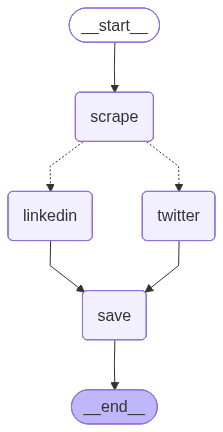

In [6]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
# Initial state
initial_state = {
    "blog_post_url": blog_post_url,
    "draft_path": "",
    "post_type": "linkedin",  # Change to "twitter" or "linkedin"
    "draft_content": "",
    "analysis": "",
    "plan": {},
    "messages": []
}

print(">>> Running for LinkedIn...")
print(f">>> Platform: {initial_state['post_type']}")

# Run the graph
result = app.invoke(initial_state)

print("\n>>> Execution complete!")
print(f">>> Output saved to: output/")

>>> Running for LinkedIn...
>>> Platform: linkedin
# fetching draft from: https://huggingface.co/blog/llama4-release
File saved to: assets/llama4-release.md
# Planning content for: assets/llama4-release.md
# Analyzing draft...
Analysis complete: 4932 characters
# Creating LinkedIn post plan...

# Planned content for assets/llama4-release.md:
#429 – Hugging Face Explained

The core idea is to highlight Hugging Face’s role in enabling large language models, datasets, and enterprise solutions. It emphasizes the importance of Hugging Face’s APIs and the necessity of an HF account to access services like model training, inference, and enterprise pricing.

**Key Technical Sections**

**1. Models**
- Hugging Face provides model APIs for developers to train and deploy large language models.
- Example: [![Image 3](https://huggingface.co/front/assets/huggingface_logo_unhappy.svg)](https://huggingface.co/models) (Visual: Hugging Face logo with model icons)

**2. APIs & Services**
- HF offers tool

In [8]:
for msg in result["messages"]:
    msg.pretty_print()

================================ System Message ================================

Draft Analyzer

================================ Human Message =================================

Analyze the markdown file at {draft_path} to create a developer-focused
technical overview

1. Map out the core idea that the blog discusses

2. Identify key sections and what each section is about

3. For each section, extract all URLs that appear inside image markdown syntax ![](image_url)

4. You must associate these identified image urls to their correspoinding sections, so that we can use them with the tweets as media pieces

Focus on details that are important for a comprehensive understanding of
the blog.


Draft Content:
Title: 429 – Hugging Face

URL Source: https://huggingface.co/blog/llama4-release


Markdown Content:
429 – Hugging Face

[![Image 2: Hugging Face's logo](https://huggingface.co/front/assets/huggingface_logo-noborder.svg)Hugging Face](https://huggingface.co/)

*   [Models](https://hug

In [9]:
print(result)

{'blog_post_url': 'https://huggingface.co/blog/llama4-release', 'draft_path': 'assets/llama4-release.md', 'post_type': 'linkedin', 'draft_content': "Title: 429 – Hugging Face\n\nURL Source: https://huggingface.co/blog/llama4-release\n\nWarning: Target URL returned error 429: Too Many Requests\n\nMarkdown Content:\n429 – Hugging Face\n===============\n\n[![Image 2: Hugging Face's logo](https://huggingface.co/front/assets/huggingface_logo-noborder.svg)Hugging Face](https://huggingface.co/)\n\n*   [Models](https://huggingface.co/models)\n*   [Datasets](https://huggingface.co/datasets)\n*   [Spaces](https://huggingface.co/spaces)\n*    Community  \n*   [Docs](https://huggingface.co/docs)\n*   [Enterprise](https://huggingface.co/enterprise)\n*   [Pricing](https://huggingface.co/pricing)\n*    \n*   \n* * *\n\n*   [Log In](https://huggingface.co/login)\n*   [Sign Up](https://huggingface.co/join)\n\n![Image 3](https://huggingface.co/front/assets/huggingface_logo_unhappy.svg)\n\n429\n===\n\nWe